In [2]:
import pandas as pd

df = pd.read_excel("Book2.xlsx")

print(df.columns)

df.info()

df.head()

Index(['Punto', 'NODO', 'RSRP', 'RSRQ', 'SINR ( RSSNR)', 'COORDENADAS',
       'BANDA'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Punto          48 non-null     int64 
 1   NODO           48 non-null     object
 2   RSRP           48 non-null     int64 
 3   RSRQ           48 non-null     int64 
 4   SINR ( RSSNR)  48 non-null     int64 
 5   COORDENADAS    48 non-null     object
 6   BANDA          48 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 2.8+ KB


,Punto,NODO,RSRP,RSRQ,SINR ( RSSNR),COORDENADAS,BANDA
0,1,100810-13,-63,-11,6,-12.056889° - 77.079995,4
1,2,100810-13,-67,-14,3,-12.056965° -77.080037°,4
2,3,100810-13,-65,-14,8,-12.057008° -77.080158°,4
3,4,100810-13,-62,-10,15,-12.057022° -77.080272°,4
4,5,100810-13,-55,-9,16,-12.057047° -77.080368°,4


In [3]:
print(df.columns)
df.info()
df.head()

Index(['Punto', 'NODO', 'RSRP', 'RSRQ', 'SINR ( RSSNR)', 'COORDENADAS',
       'BANDA'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Punto          48 non-null     int64 
 1   NODO           48 non-null     object
 2   RSRP           48 non-null     int64 
 3   RSRQ           48 non-null     int64 
 4   SINR ( RSSNR)  48 non-null     int64 
 5   COORDENADAS    48 non-null     object
 6   BANDA          48 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 2.8+ KB


,Punto,NODO,RSRP,RSRQ,SINR ( RSSNR),COORDENADAS,BANDA
0,1,100810-13,-63,-11,6,-12.056889° - 77.079995,4
1,2,100810-13,-67,-14,3,-12.056965° -77.080037°,4
2,3,100810-13,-65,-14,8,-12.057008° -77.080158°,4
3,4,100810-13,-62,-10,15,-12.057022° -77.080272°,4
4,5,100810-13,-55,-9,16,-12.057047° -77.080368°,4


In [4]:
df["COORDENADAS"].head(5)

0    -12.056889° - 77.079995
1    -12.056965° -77.080037°
2    -12.057008° -77.080158°
3    -12.057022° -77.080272°
4    -12.057047° -77.080368°
Name: COORDENADAS, dtype: object

In [5]:
# ==========================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Procesamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Mapas interactivos
import folium
from folium import plugins
from folium.raster_layers import ImageOverlay

# Interpolación
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist

# Distancias geográficas
from geopy.distance import geodesic

# Escalas de colores
import matplotlib.cm as cm
import matplotlib.colors as colors

# Leyendas para Folium
from branca.colormap import LinearColormap

In [6]:
# ==========================================================
# 2. CARGA DE LOS DATOS
# ==========================================================

archivo = "Book2.xlsx"

df = pd.read_excel(archivo)

print("Dimensiones del DataFrame:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns)

display(df.head())

Dimensiones del DataFrame:
(48, 7)

Columnas disponibles:
Index(['Punto', 'NODO', 'RSRP', 'RSRQ', 'SINR ( RSSNR)', 'COORDENADAS',
       'BANDA'],
      dtype='object')


,Punto,NODO,RSRP,RSRQ,SINR ( RSSNR),COORDENADAS,BANDA
0,1,100810-13,-63,-11,6,-12.056889° - 77.079995,4
1,2,100810-13,-67,-14,3,-12.056965° -77.080037°,4
2,3,100810-13,-65,-14,8,-12.057008° -77.080158°,4
3,4,100810-13,-62,-10,15,-12.057022° -77.080272°,4
4,5,100810-13,-55,-9,16,-12.057047° -77.080368°,4


In [7]:
import re
import pandas as pd
import numpy as np

def separar_coord(texto):

    if pd.isna(texto):
        return pd.Series([np.nan, np.nan])

    texto = str(texto)

    # Quitar símbolo °
    texto = texto.replace("°", "")

    # Normalizar el separador
    texto = texto.replace(" - ", " -")

    nums = re.findall(r'-?\d+\.\d+', texto)

    if len(nums) != 2:
        print("Coordenada inválida:", texto)
        return pd.Series([np.nan, np.nan])

    return pd.Series([float(nums[0]), float(nums[1])])

df[["Latitud","Longitud"]] = df["COORDENADAS"].apply(separar_coord)

In [8]:
df[["COORDENADAS","Latitud","Longitud"]].head()

,COORDENADAS,Latitud,Longitud
0,-12.056889° - 77.079995,-12.056889,-77.079995
1,-12.056965° -77.080037°,-12.056965,-77.080037
2,-12.057008° -77.080158°,-12.057008,-77.080158
3,-12.057022° -77.080272°,-12.057022,-77.080272
4,-12.057047° -77.080368°,-12.057047,-77.080368


In [9]:
# ==========================================================
# 4. VERIFICACIÓN DEL CONJUNTO DE DATOS
# ==========================================================

print("="*60)
print("Dimensiones del conjunto de datos")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Valores nulos")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("Tipos de datos")
print("="*60)
print(df.dtypes)

print("\n")

print("="*60)
print("Resumen estadístico")
print("="*60)

display(df.describe())

Dimensiones del conjunto de datos
(48, 9)


Valores nulos
Punto            0
NODO             0
RSRP             0
RSRQ             0
SINR ( RSSNR)    0
COORDENADAS      0
BANDA            0
Latitud          0
Longitud         0
dtype: int64


Tipos de datos
Punto              int64
NODO              object
RSRP               int64
RSRQ               int64
SINR ( RSSNR)      int64
COORDENADAS       object
BANDA              int64
Latitud          float64
Longitud         float64
dtype: object


Resumen estadístico


,Punto,RSRP,RSRQ,SINR ( RSSNR),BANDA,Latitud,Longitud
count,48.00,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,24.50,-75.562500,-13.333333,8.270833,6.916667,-12.056700,-77.081216
std,14.00,10.662933,2.890434,5.526492,8.102622,0.000613,0.000750
min,1.00,-97.000000,-20.000000,-3.000000,2.000000,-12.057522,-77.082483
25%,12.75,-84.250000,-14.250000,4.750000,4.000000,-12.057202,-77.081842
50%,24.50,-76.000000,-13.000000,8.000000,4.000000,-12.056895,-77.081243
75%,36.25,-66.000000,-11.000000,11.500000,5.000000,-12.056191,-77.080460
max,48.00,-55.000000,-9.000000,20.000000,28.000000,-12.055485,-77.079995


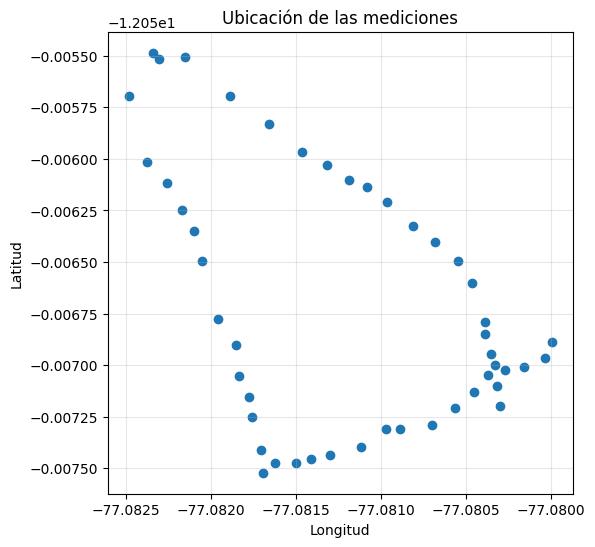

In [10]:
# Coordenadas obtenidas

plt.figure(figsize=(6,6))

plt.scatter(
    df["Longitud"],
    df["Latitud"]
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.title("Ubicación de las mediciones")

plt.grid(alpha=0.3)

plt.show()

In [11]:
# =====================================================
# 4. Verificación del conjunto de datos
# =====================================================

print("="*60)
print("Dimensiones del conjunto de datos")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Valores faltantes")
print("="*60)

display(df.isnull().sum())

print("\n")

print("="*60)
print("Tipos de datos")
print("="*60)

display(df.dtypes)

print("\n")

print("="*60)
print("Resumen estadístico")
print("="*60)

display(df.describe())

Dimensiones del conjunto de datos
(48, 9)


Valores faltantes


Punto            0
NODO             0
RSRP             0
RSRQ             0
SINR ( RSSNR)    0
COORDENADAS      0
BANDA            0
Latitud          0
Longitud         0
dtype: int64



Tipos de datos


Punto              int64
NODO              object
RSRP               int64
RSRQ               int64
SINR ( RSSNR)      int64
COORDENADAS       object
BANDA              int64
Latitud          float64
Longitud         float64
dtype: object



Resumen estadístico


,Punto,RSRP,RSRQ,SINR ( RSSNR),BANDA,Latitud,Longitud
count,48.00,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,24.50,-75.562500,-13.333333,8.270833,6.916667,-12.056700,-77.081216
std,14.00,10.662933,2.890434,5.526492,8.102622,0.000613,0.000750
min,1.00,-97.000000,-20.000000,-3.000000,2.000000,-12.057522,-77.082483
25%,12.75,-84.250000,-14.250000,4.750000,4.000000,-12.057202,-77.081842
50%,24.50,-76.000000,-13.000000,8.000000,4.000000,-12.056895,-77.081243
75%,36.25,-66.000000,-11.000000,11.500000,5.000000,-12.056191,-77.080460
max,48.00,-55.000000,-9.000000,20.000000,28.000000,-12.055485,-77.079995


In [12]:
# =====================================================
# 5.1 Crear mapa base
# =====================================================

centro = [

    df["Latitud"].mean(),

    df["Longitud"].mean()

]

mapa = folium.Map(

    location=centro,

    zoom_start=18,

    tiles="OpenStreetMap"

)

mapa

In [13]:
# =====================================================
# 5.2 Agregar estación base
# =====================================================

bts = df.iloc[0]

folium.CircleMarker(

    location=[bts["Latitud"], bts["Longitud"]],

    radius=9,

    color="red",

    fill=True,

    fill_color="red",

    fill_opacity=1,

    popup="""

    <b>Estación Base (BTS)</b>

    <br>

    Punto 1

    """

).add_to(mapa)

mapa

In [14]:
# =====================================================
# 5.3 Dibujar recorrido
# =====================================================

ruta = list(zip(df["Latitud"], df["Longitud"]))

folium.PolyLine(

    ruta,

    weight=4,

    tooltip="Ruta de medición"

).add_to(mapa)

display(mapa)

In [15]:
# =====================================================
# 6.1 Coordenadas de la estación base (BTS)
# =====================================================

# El Punto 1 corresponde a la estación base
bts = (
    df.loc[0, "Latitud"],
    df.loc[0, "Longitud"]
)

print("Coordenadas BTS:", bts)

Coordenadas BTS: (np.float64(-12.056889), np.float64(-77.079995))


In [16]:
# =====================================================
# 6.1 Distribución de nodos
# =====================================================

conteo_nodos = (
    df["NODO"]
    .value_counts()
    .reset_index()
)

conteo_nodos.columns = ["Nodo", "Cantidad de mediciones"]

display(conteo_nodos)

,Nodo,Cantidad de mediciones
0,100810-13,20
1,100810-26,9
2,100810-9,7
3,100810-6,6
4,100810-1,5
5,100244-6,1


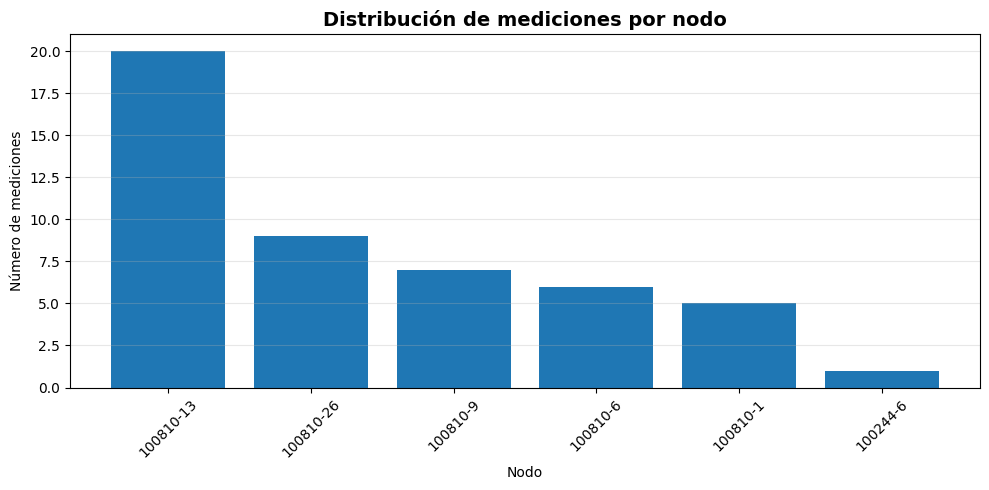

In [17]:
# =====================================================
# 6.2 Cantidad de mediciones por nodo
# =====================================================

conteo = df["NODO"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    conteo.index,
    conteo.values
)

plt.xlabel("Nodo")

plt.ylabel("Número de mediciones")

plt.title(
    "Distribución de mediciones por nodo",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figuras/Nodos.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [18]:
# =====================================================
# 6.3 Nodo seleccionado
# =====================================================

NODO_PRINCIPAL = "100810-13"

df_nodo = df[
    df["NODO"] == NODO_PRINCIPAL
].copy()

print(f"Nodo seleccionado: {NODO_PRINCIPAL}")

print(f"Cantidad de puntos: {len(df_nodo)}")

Nodo seleccionado: 100810-13
Cantidad de puntos: 20


In [19]:
# =====================================================
# 6.4 Resaltar nodo principal
# =====================================================

for _, fila in df.iterrows():

    if fila["NODO"] == NODO_PRINCIPAL:

        color = "green"
        radio = 6

    else:

        color = "gray"
        radio = 4

    popup = f"""
    <b>Punto:</b> {fila['Punto']}<br>
    <b>Nodo:</b> {fila['NODO']}<br>
    <b>RSRP:</b> {fila['RSRP']} dBm
    """

    folium.CircleMarker(

        location=[fila["Latitud"], fila["Longitud"]],

        radius=radio,

        color=color,

        fill=True,

        fill_color=color,

        fill_opacity=0.85,

        popup=popup

    ).add_to(mapa)

mapa

In [20]:
# =====================================================
# 6.5 Crear mapa del nodo seleccionado
# =====================================================

centro = [
    df_nodo.iloc[0]["Latitud"],
    df_nodo.iloc[0]["Longitud"]
]

mapa_nodo = folium.Map(

    location=centro,

    zoom_start=18,

    tiles="OpenStreetMap"

)

mapa_nodo

In [21]:
# =====================================================
# 6.6 Recorrido del nodo seleccionado
# =====================================================

ruta = list(zip(df_nodo["Latitud"], df_nodo["Longitud"]))

folium.PolyLine(

    ruta,

    weight=5,

    color="blue",

    tooltip="Recorrido del nodo seleccionado"

).add_to(mapa_nodo)

mapa_nodo

In [22]:
# =====================================================
# 6.7 Estación Base
# =====================================================

bts = df.iloc[0]

folium.CircleMarker(

    location=[bts["Latitud"], bts["Longitud"]],

    radius=9,

    color="red",

    fill=True,

    fill_color="red",

    fill_opacity=1,

    popup="<b>Estación Base (BTS)</b>"

).add_to(mapa_nodo)

mapa_nodo

In [23]:
# =====================================================
# 7.1 Coordenadas de la BTS
# =====================================================

lat_bts = df_nodo.iloc[0]["Latitud"]

lon_bts = df_nodo.iloc[0]["Longitud"]

print(f"Latitud BTS : {lat_bts}")

print(f"Longitud BTS: {lon_bts}")

Latitud BTS : -12.056889
Longitud BTS: -77.079995


In [24]:
# =====================================================
# 7.2 Distancia respecto a la BTS
# =====================================================

from geopy.distance import geodesic

distancias = []

for _, fila in df_nodo.iterrows():

    distancia = geodesic(

        (lat_bts, lon_bts),

        (fila["Latitud"], fila["Longitud"])

    ).meters

    distancias.append(distancia)

df_nodo["Distancia (m)"] = distancias

df_nodo.head()

,Punto,NODO,RSRP,RSRQ,SINR ( RSSNR),COORDENADAS,BANDA,Latitud,Longitud,Distancia (m)
0,1,100810-13,-63,-11,6,-12.056889° - 77.079995,4,-12.056889,-77.079995,0.000000
1,2,100810-13,-67,-14,3,-12.056965° -77.080037°,4,-12.056965,-77.080037,9.570529
2,3,100810-13,-65,-14,8,-12.057008° -77.080158°,4,-12.057008,-77.080158,22.096692
3,4,100810-13,-62,-10,15,-12.057022° -77.080272°,4,-12.057022,-77.080272,33.557024
4,5,100810-13,-55,-9,16,-12.057047° -77.080368°,4,-12.057047,-77.080368,44.213573


In [25]:
# =====================================================
# 7.3 Verificación de distancias
# =====================================================

df_nodo[[
    "Punto",
    "Distancia (m)",
    "RSRP"
]]

,Punto,Distancia (m),RSRP
0,1,0.000000,-63
1,2,9.570529,-67
2,3,22.096692,-65
3,4,33.557024,-62
4,5,44.213573,-55
5,6,56.650810,-68
6,7,71.218937,-68
7,8,88.373469,-65
8,9,108.007495,-66
9,10,116.179116,-73


In [26]:
def color_rsrp(rsrp):

    if rsrp >= -80:
        return "green"

    elif rsrp >= -90:
        return "yellow"

    elif rsrp >= -100:
        return "orange"

    else:
        return "red"

In [27]:
# =====================================================
# 7.5 Puntos de medición
# =====================================================

for _, fila in df_nodo.iterrows():

    popup = f"""
    <b>Punto:</b> {fila['Punto']}<br>

    <b>Nodo:</b> {fila['NODO']}<br>

    <b>Distancia:</b> {fila['Distancia (m)']:.1f} m<br>

    <b>RSRP:</b> {fila['RSRP']} dBm<br>

    <b>RSRQ:</b> {fila['RSRQ']} dB<br>

    <b>SINR:</b> {fila['SINR ( RSSNR)']} dB<br>

    <b>Banda:</b> B{fila['BANDA']}
    """

    # Círculo
    folium.CircleMarker(

        location=[fila["Latitud"], fila["Longitud"]],

        radius=6,

        color="black",

        weight=1,

        fill=True,

        fill_color=color_rsrp(fila["RSRP"]),

        fill_opacity=0.85,

        popup=popup

    ).add_to(mapa_nodo)

    # Número
    folium.Marker(

        location=[fila["Latitud"], fila["Longitud"]],

        icon=folium.DivIcon(

            html=f"""
            <div style="
                font-size:9pt;
                font-weight:bold;
                color:black;
            ">
            {fila['Punto']}
            </div>
            """

        )

    ).add_to(mapa_nodo)

mapa_nodo

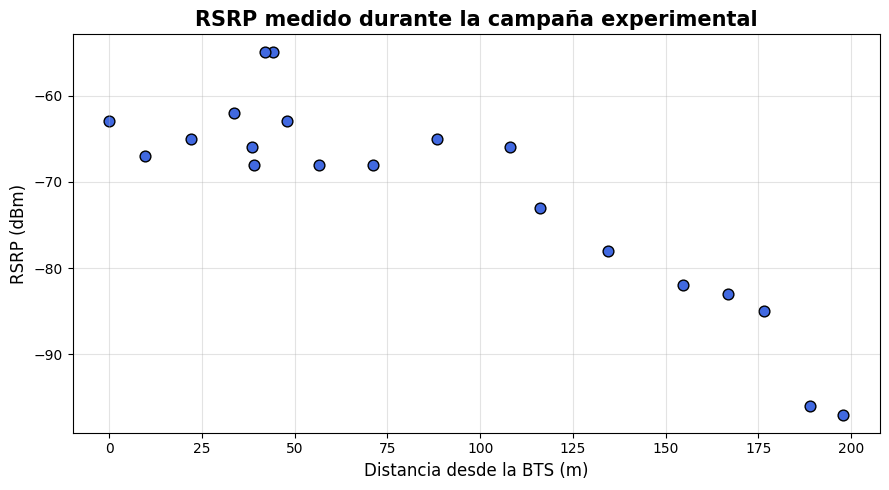

In [28]:
# =====================================================
# 8.1 RSRP experimental
# =====================================================

plt.figure(figsize=(9,5))

plt.scatter(

    df_nodo["Distancia (m)"],

    df_nodo["RSRP"],

    s=60,

    color="royalblue",

    edgecolors="black"

)

plt.grid(alpha=0.35)

plt.xlabel(

    "Distancia desde la BTS (m)",

    fontsize=12

)

plt.ylabel(

    "RSRP (dBm)",

    fontsize=12

)

plt.title(

    "RSRP medido durante la campaña experimental",

    fontsize=15,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    "figuras/RSRP_Experimental.png",

    dpi=400,

    bbox_inches="tight"

)

plt.show()

In [29]:
# =====================================================
# 8.2 Ajuste logarítmico del RSRP
# =====================================================

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Evitar log(0)
datos = df_nodo.copy()

datos = datos[datos["Distancia (m)"] > 0]

x = datos["Distancia (m)"].values

y = datos["RSRP"].values

# Modelo logarítmico
def modelo_log(d, a, b):

    return a + b*np.log10(d)

# Ajuste
parametros, _ = curve_fit(modelo_log, x, y)

a, b = parametros

# Valores ajustados
y_pred = modelo_log(x, a, b)

# Coeficiente R²
r2 = r2_score(y, y_pred)

print(f"a = {a:.3f}")

print(f"b = {b:.3f}")

print(f"R² = {r2:.4f}")

a = -26.788
b = -24.381
R² = 0.5296


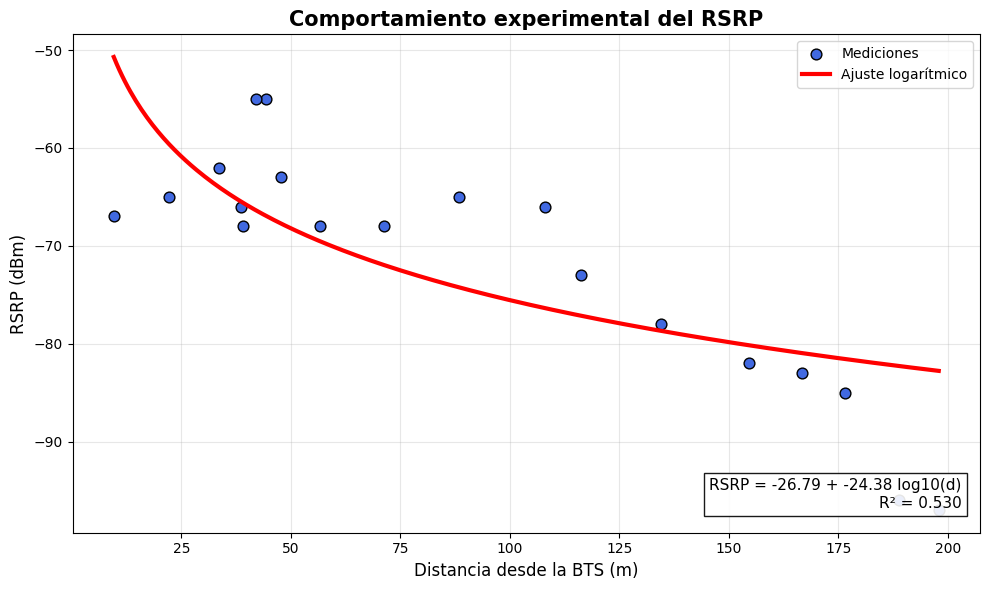

In [30]:
# =====================================================
# 8.3 Ajuste experimental
# =====================================================

plt.figure(figsize=(10,6))

# Mediciones
plt.scatter(

    x,

    y,

    s=60,

    color="royalblue",

    edgecolors="black",

    label="Mediciones"

)

# Curva ajustada
x_modelo = np.linspace(

    x.min(),

    x.max(),

    300

)

plt.plot(

    x_modelo,

    modelo_log(x_modelo, a, b),

    color="red",

    linewidth=3,

    label="Ajuste logarítmico"

)

plt.grid(alpha=0.3)

plt.xlabel(

    "Distancia desde la BTS (m)",

    fontsize=12

)

plt.ylabel(

    "RSRP (dBm)",

    fontsize=12

)

plt.title(

    "Comportamiento experimental del RSRP",

    fontsize=15,

    fontweight="bold"

)

plt.legend()

# Mostrar ecuación
texto = (
    f"RSRP = {a:.2f} + {b:.2f} log10(d)\n"
    f"R² = {r2:.3f}"
)

plt.text(

    0.98,

    0.05,

    texto,

    transform=plt.gca().transAxes,

    fontsize=11,

    ha="right",

    bbox=dict(

        facecolor="white",

        alpha=0.9,

        edgecolor="black"

    )

)

plt.tight_layout()

plt.savefig(

    "figuras/RSRP_Ajuste_Logaritmico.png",

    dpi=400,

    bbox_inches="tight"

)

plt.show()

In [31]:
# =====================================================
# 9.1 Parámetros COST-231 Hata
# =====================================================

import numpy as np

# Frecuencia LTE
f = 1720      # MHz

# Altura BTS
hb = 15       # metros

# Altura móvil
hm = 1.5      # metros

# Ciudad urbana
C = 3         # dB

In [32]:
# =====================================================
# Corrección altura móvil
# =====================================================

a_hm = (1.1*np.log10(f)-0.7)*hm - (1.56*np.log10(f)-0.8)

print(a_hm)

0.04119756022167831


In [33]:
# =====================================================
# Path Loss COST-231 Hata
# =====================================================

# Evitar log(0)
df_nodo["Distancia_km"] = df_nodo["Distancia (m)"]/1000

df_nodo.loc[df_nodo["Distancia_km"] < 0.001,"Distancia_km"] = 0.001

d = df_nodo["Distancia_km"]

L = (
46.3
+33.9*np.log10(f)
-13.82*np.log10(hb)
-a_hm
+(44.9-6.55*np.log10(hb))*np.log10(d)
+C
)

df_nodo["PathLoss_COST231"] = L

df_nodo.head()

,Punto,NODO,RSRP,RSRQ,SINR ( RSSNR),COORDENADAS,BANDA,Latitud,Longitud,Distancia (m),Distancia_km,PathLoss_COST231
0,1,100810-13,-63,-11,6,-12.056889° - 77.079995,4,-12.056889,-77.079995,0.000000,0.001000,31.099829
1,2,100810-13,-67,-14,3,-12.056965° -77.080037°,4,-12.056965,-77.080037,9.570529,0.009571,67.587314
2,3,100810-13,-65,-14,8,-12.057008° -77.080158°,4,-12.057008,-77.080158,22.096692,0.022097,81.104235
3,4,100810-13,-62,-10,15,-12.057022° -77.080272°,4,-12.057022,-77.080272,33.557024,0.033557,87.853789
4,5,100810-13,-55,-9,16,-12.057047° -77.080368°,4,-12.057047,-77.080368,44.213573,0.044214,92.308907


In [34]:
# =====================================================
# RSRP teórico
# =====================================================

# =====================================================
# Ajuste automático de la constante del modelo
# =====================================================

A = np.mean(

    df_nodo["RSRP"]

    +

    df_nodo["PathLoss_COST231"]

)

df_nodo["RSRP_COST231"] = A - df_nodo["PathLoss_COST231"]

print("Constante A =", round(A,2), "dBm")

df_nodo.head()

Constante A = 24.92 dBm


,Punto,NODO,RSRP,RSRQ,SINR ( RSSNR),COORDENADAS,BANDA,Latitud,Longitud,Distancia (m),Distancia_km,PathLoss_COST231,RSRP_COST231
0,1,100810-13,-63,-11,6,-12.056889° - 77.079995,4,-12.056889,-77.079995,0.000000,0.001000,31.099829,-6.180067
1,2,100810-13,-67,-14,3,-12.056965° -77.080037°,4,-12.056965,-77.080037,9.570529,0.009571,67.587314,-42.667552
2,3,100810-13,-65,-14,8,-12.057008° -77.080158°,4,-12.057008,-77.080158,22.096692,0.022097,81.104235,-56.184474
3,4,100810-13,-62,-10,15,-12.057022° -77.080272°,4,-12.057022,-77.080272,33.557024,0.033557,87.853789,-62.934027
4,5,100810-13,-55,-9,16,-12.057047° -77.080368°,4,-12.057047,-77.080368,44.213573,0.044214,92.308907,-67.389145


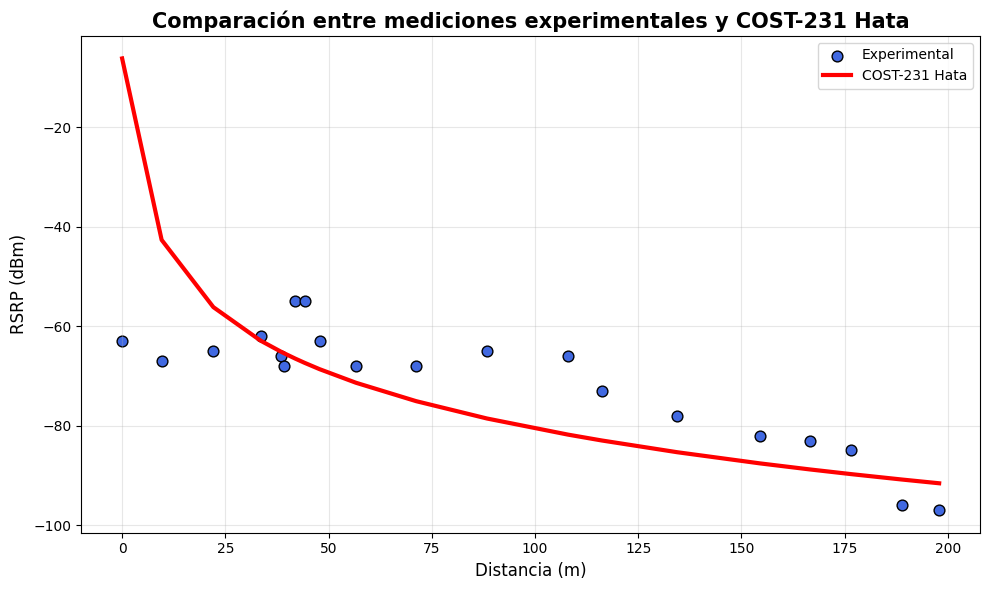

In [35]:
# =====================================================
# Comparación
# =====================================================

plt.figure(figsize=(10,6))
df_plot = df_nodo.sort_values("Distancia (m)")
plt.scatter(
    df_plot["Distancia (m)"],
    df_plot["RSRP"],
    s=60,
    color="royalblue",
    edgecolors="black",
    label="Experimental"
)

plt.plot(
    df_plot["Distancia (m)"],
    df_plot["RSRP_COST231"],
    color="red",
    linewidth=3,
    label="COST-231 Hata"
)

plt.grid(alpha=0.3)

plt.xlabel("Distancia (m)",fontsize=12)

plt.ylabel("RSRP (dBm)",fontsize=12)

plt.title(

    "Comparación entre mediciones experimentales y COST-231 Hata",

    fontsize=15,

    fontweight="bold"

)

plt.legend()

plt.tight_layout()

plt.savefig(

    "figuras/Comparacion_COST231.png",

    dpi=400,

    bbox_inches="tight"

)

plt.show()

In [36]:
# =====================================================
# 5.8.1 Error del modelo COST-231
# =====================================================

df_nodo["Error (dB)"] = (

    df_nodo["RSRP"]

    -

    df_nodo["RSRP_COST231"]

)

display(

    df_nodo[

        [

            "Punto",

            "RSRP",

            "RSRP_COST231",

            "Error (dB)"

        ]

    ]

)

,Punto,RSRP,RSRP_COST231,Error (dB)
0,1,-63,-6.180067,-56.819933
1,2,-67,-42.667552,-24.332448
2,3,-65,-56.184474,-8.815526
3,4,-62,-62.934027,0.934027
4,5,-55,-67.389145,12.389145
5,6,-68,-71.393378,3.393378
6,7,-68,-75.090325,7.090325
7,8,-65,-78.576629,13.576629
8,9,-66,-81.817643,15.817643
9,10,-73,-82.995815,9.995815


In [37]:
# =====================================================
# 5.8.2 Indicadores del modelo
# =====================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(

    df_nodo["RSRP"],

    df_nodo["RSRP_COST231"]

)

rmse = np.sqrt(

    mean_squared_error(

        df_nodo["RSRP"],

        df_nodo["RSRP_COST231"]

    )

)

r2 = r2_score(

    df_nodo["RSRP"],

    df_nodo["RSRP_COST231"]

)

print(f"MAE  : {mae:.2f} dB")
print(f"RMSE : {rmse:.2f} dB")
print(f"R²   : {r2:.3f}")

MAE  : 10.39 dB
RMSE : 15.84 dB
R²   : -0.859


In [38]:
# =====================================================
# 5.8.1 Error entre medición y modelo
# =====================================================

df_nodo["Error (dB)"] = (

    df_nodo["RSRP"]

    -

    df_nodo["RSRP_COST231"]

)

display(

    df_nodo[

        [

            "Punto",

            "Distancia (m)",

            "RSRP",

            "RSRP_COST231",

            "Error (dB)"

        ]

    ]

)

,Punto,Distancia (m),RSRP,RSRP_COST231,Error (dB)
0,1,0.000000,-63,-6.180067,-56.819933
1,2,9.570529,-67,-42.667552,-24.332448
2,3,22.096692,-65,-56.184474,-8.815526
3,4,33.557024,-62,-62.934027,0.934027
4,5,44.213573,-55,-67.389145,12.389145
5,6,56.650810,-68,-71.393378,3.393378
6,7,71.218937,-68,-75.090325,7.090325
7,8,88.373469,-65,-78.576629,13.576629
8,9,108.007495,-66,-81.817643,15.817643
9,10,116.179116,-73,-82.995815,9.995815


In [39]:
# =====================================================
# 5.8.2 Métricas del modelo
# =====================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(

    df_nodo["RSRP"],

    df_nodo["RSRP_COST231"]

)

rmse = np.sqrt(

    mean_squared_error(

        df_nodo["RSRP"],

        df_nodo["RSRP_COST231"]

    )

)

r2 = r2_score(

    df_nodo["RSRP"],

    df_nodo["RSRP_COST231"]

)

print(f"MAE  : {mae:.2f} dB")

print(f"RMSE : {rmse:.2f} dB")

print(f"R²   : {r2:.3f}")

MAE  : 10.39 dB
RMSE : 15.84 dB
R²   : -0.859


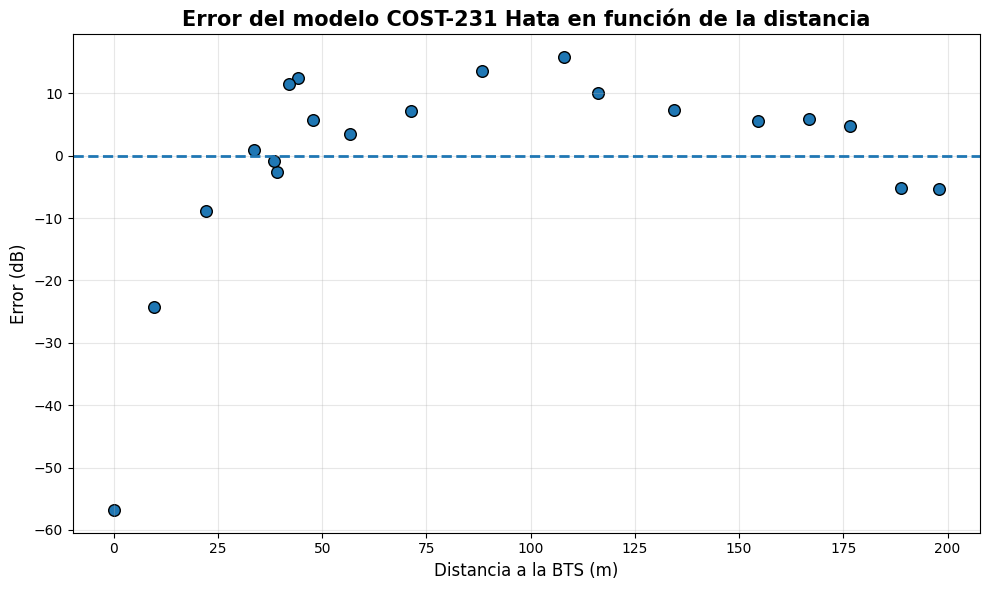

In [40]:
# =====================================================
# 5.8.3 Error del modelo
# =====================================================

plt.figure(figsize=(10,6))

plt.scatter(

    df_nodo["Distancia (m)"],

    df_nodo["Error (dB)"],

    s=70,

    edgecolors="black"

)

plt.axhline(

    y=0,

    linestyle="--",

    linewidth=2

)

plt.grid(alpha=0.3)

plt.xlabel(

    "Distancia a la BTS (m)",

    fontsize=12

)

plt.ylabel(

    "Error (dB)",

    fontsize=12

)

plt.title(

    "Error del modelo COST-231 Hata en función de la distancia",

    fontsize=15,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    "figuras/Error_vs_Distancia.png",

    dpi=400,

    bbox_inches="tight"

)

plt.show()

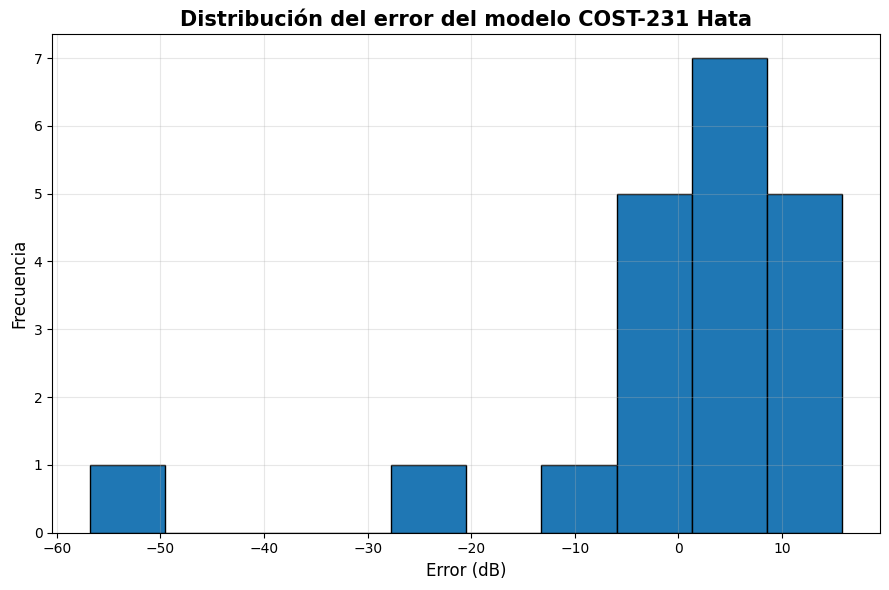

In [41]:
# =====================================================
# 5.8.4 Distribución del error
# =====================================================

plt.figure(figsize=(9,6))

plt.hist(

    df_nodo["Error (dB)"],

    bins=10,

    edgecolor="black"

)

plt.grid(alpha=0.3)

plt.xlabel(

    "Error (dB)",

    fontsize=12

)

plt.ylabel(

    "Frecuencia",

    fontsize=12

)

plt.title(

    "Distribución del error del modelo COST-231 Hata",

    fontsize=15,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    "figuras/Histograma_Error.png",

    dpi=400,

    bbox_inches="tight"

)

plt.show()

In [42]:
from folium.plugins import HeatMap

In [43]:
# =====================================================
# 5.9.1 REM Experimental
# =====================================================

mapa_exp = folium.Map(

    location=[

        df_nodo["Latitud"].mean(),

        df_nodo["Longitud"].mean()

    ],

    zoom_start=19,

    tiles="OpenStreetMap"

)

In [44]:
# =====================================================
# Datos para HeatMap
# =====================================================

datos_heat=[]

for _,fila in df_nodo.iterrows():

    datos_heat.append([

        fila["Latitud"],

        fila["Longitud"],

        fila["RSRP"]+120

    ])

In [45]:
HeatMap(

    datos_heat,

    radius=30,

    blur=20,

    min_opacity=0.40,

    max_zoom=20

).add_to(mapa_exp)

In [46]:
folium.CircleMarker(

    [lat_bts,lon_bts],

    radius=8,

    color="red",

    fill=True,

    fill_color="red",

    popup="BTS"

).add_to(mapa_exp)

In [47]:
folium.PolyLine(

    ruta,

    weight=3,

    color="black"

).add_to(mapa_exp)

In [48]:
mapa_exp.save(

    "REM_Experimental.html"

)

mapa_exp

In [49]:
# =====================================================
# 5.9.1 Error absoluto
# =====================================================

df_nodo["Error Absoluto"] = abs(

    df_nodo["RSRP"]

    -

    df_nodo["RSRP_COST231"]

)

display(

    df_nodo[

        [

            "Punto",

            "Error Absoluto"

        ]

    ]

)

,Punto,Error Absoluto
0,1,56.819933
1,2,24.332448
2,3,8.815526
3,4,0.934027
4,5,12.389145
5,6,3.393378
6,7,7.090325
7,8,13.576629
8,9,15.817643
9,10,9.995815


In [50]:
# =====================================================
# 5.9.2 Mapa del Error
# =====================================================

mapa_error = folium.Map(

    location=[

        df_nodo["Latitud"].mean(),

        df_nodo["Longitud"].mean()

    ],

    zoom_start=19,

    tiles="OpenStreetMap"

)

In [51]:
folium.CircleMarker(

    [lat_bts,lon_bts],

    radius=9,

    color="red",

    fill=True,

    fill_color="red",

    popup="BTS"

).add_to(mapa_error)

In [52]:
folium.PolyLine(

    ruta,

    weight=3,

    color="black",

    tooltip="Ruta de medición"

).add_to(mapa_error)

In [53]:
# =====================================================
# Colores según el error
# =====================================================

def color_error(error):

    if error <= 3:
        return "green"

    elif error <= 6:
        return "yellow"

    elif error <= 10:
        return "orange"

    else:
        return "red"

In [54]:
for _, fila in df_nodo.iterrows():

    popup = f"""

    <b>Punto:</b> {fila['Punto']}<br>

    <b>Error:</b> {fila['Error Absoluto']:.2f} dB<br>

    <b>RSRP Experimental:</b> {fila['RSRP']} dBm<br>

    <b>RSRP COST231:</b> {fila['RSRP_COST231']:.2f} dBm

    """

    folium.CircleMarker(

        location=[

            fila["Latitud"],

            fila["Longitud"]

        ],

        radius=8,

        color="black",

        weight=1,

        fill=True,

        fill_color=color_error(

            fila["Error Absoluto"]

        ),

        fill_opacity=0.9,

        popup=popup

    ).add_to(mapa_error)

In [55]:
from branca.element import MacroElement
from jinja2 import Template

legend = """

{% macro html(this, kwargs) %}

<div style="

position: fixed;

bottom: 50px;

left: 50px;

width: 210px;

background:white;

border:2px solid gray;

padding:10px;

z-index:9999;

font-size:14px;

border-radius:8px;

">

<b>Error del Modelo</b><br><br>

🟢 0 - 3 dB<br>

🟡 3 - 6 dB<br>

🟠 6 - 10 dB<br>

🔴 >10 dB

</div>

{% endmacro %}

"""

macro = MacroElement()

macro._template = Template(legend)

mapa_error.get_root().add_child(macro)

In [56]:
mapa_error.save("Mapa_Error_COST231.html")

mapa_error

In [57]:
# =====================================================
# 5.10 Mapa de Dominancia de Nodos LTE
# =====================================================

import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Crear mapa
mapa_nodos = folium.Map(

    location=[

        df["Latitud"].mean(),

        df["Longitud"].mean()

    ],

    zoom_start=18,

    tiles="OpenStreetMap"

)

In [58]:
# =====================================================
# Colores para cada nodo
# =====================================================

nodos = sorted(df["NODO"].unique())

cmap = plt.cm.get_cmap("tab10", len(nodos))

colores = {}

for i, nodo in enumerate(nodos):

    colores[nodo] = mcolors.to_hex(cmap(i))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12064\4271599675.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(nodos))


In [59]:
folium.PolyLine(

    ruta,

    color="black",

    weight=3,

    tooltip="Ruta de medición"

).add_to(mapa_nodos)

In [60]:
folium.CircleMarker(

    location=[lat_bts, lon_bts],

    radius=9,

    color="red",

    fill=True,

    fill_color="red",

    popup="<b>Estación Base Inicial</b>"

).add_to(mapa_nodos)

In [61]:
for _, fila in df.iterrows():

    popup = f"""

    <b>Punto:</b> {fila['Punto']}<br>

    <b>Nodo:</b> {fila['NODO']}<br>

    <b>RSRP:</b> {fila['RSRP']} dBm

    """

    folium.CircleMarker(

        location=[

            fila["Latitud"],

            fila["Longitud"]

        ],

        radius=6,

        color="black",

        weight=1,

        fill=True,

        fill_color=colores[fila["NODO"]],

        fill_opacity=0.9,

        popup=popup

    ).add_to(mapa_nodos)

In [62]:
# =====================================================
# Leyenda de nodos
# =====================================================

legend_html = """

<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 230px;
background:white;
border:2px solid gray;
z-index:9999;
padding:10px;
font-size:13px;
border-radius:8px;
">

<b>Nodos LTE</b><br><br>

"""

for nodo in nodos:

    legend_html += f"""

    <div>

    <span style="

    display:inline-block;

    width:18px;

    height:18px;

    background:{colores[nodo]};

    border:1px solid black;

    "></span>

    &nbsp;{nodo}

    </div>

    """

legend_html += "</div>"

mapa_nodos.get_root().html.add_child(

    folium.Element(legend_html)

)

In [63]:
mapa_nodos.save("Mapa_Dominancia_Nodos.html")

mapa_nodos